In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL.Image import merge
from pandas.conftest import ascending


In [26]:
patients = pd.read_csv(r'C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Hospital_Data_Analytics_Project\Data\patients.csv')
treatments = pd.read_csv(r"C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Hospital_Data_Analytics_Project\Data\treatments.csv")
billing = pd.read_csv(r"C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Hospital_Data_Analytics_Project\Data\billing.csv")
doctors = pd.read_csv(r"C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Hospital_Data_Analytics_Project\Data\doctors.csv")
appointments = pd.read_csv(r"C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Hospital_Data_Analytics_Project\Data\appointments.csv")

In [27]:
appointments

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show
...,...,...,...,...,...,...,...
195,A196,P045,D006,2023-10-26,9:45:00,Checkup,Cancelled
196,A197,P001,D005,2023-04-01,13:30:00,Emergency,No-show
197,A198,P022,D006,2023-05-15,8:30:00,Therapy,No-show
198,A199,P017,D001,2023-05-01,12:45:00,Follow-up,Completed


In [28]:
billing

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending
...,...,...,...,...,...,...,...
195,B196,P045,T196,2023-10-26,2477.80,Cash,Pending
196,B197,P001,T197,2023-04-01,975.49,Cash,Pending
197,B198,P022,T198,2023-05-15,3383.72,Cash,Failed
198,B199,P017,T199,2023-05-01,1472.17,Credit Card,Paid


# standardizing  data types

In [29]:
patients['registration_date'] = pd.to_datetime(patients['registration_date'])
patients['date_of_birth'] = pd.to_datetime(patients['date_of_birth'])
patients['contact_number'] = patients['contact_number'].astype(str)
treatments['treatment_date'] = pd.to_datetime(treatments['treatment_date'])
billing['bill_date'] = pd.to_datetime(billing['bill_date'])
doctors['phone_number'] = doctors['phone_number'].astype(str)
appointments['appointment_date'] = pd.to_datetime(appointments['appointment_date'])



In [30]:
treatments.head()
treatments.info()
treatments.describe()
treatments.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   treatment_id    200 non-null    str           
 1   appointment_id  200 non-null    str           
 2   treatment_type  200 non-null    str           
 3   description     200 non-null    str           
 4   cost            200 non-null    float64       
 5   treatment_date  200 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 9.5 KB


treatment_id      0
appointment_id    0
treatment_type    0
description       0
cost              0
treatment_date    0
dtype: int64

# What kind of patient population does this hospital serve?

In [31]:
patients['gender'].value_counts()

gender
M    31
F    19
Name: count, dtype: int64

In [32]:
patients['insurance_provider'].value_counts()

insurance_provider
MedCare Plus    18
WellnessCorp    16
PulseSecure     10
HealthIndia      6
Name: count, dtype: int64

In [33]:
patients['age'] = (2024 - patients['date_of_birth'].dt.year).astype(int)
patients['age'].dtype

dtype('int64')

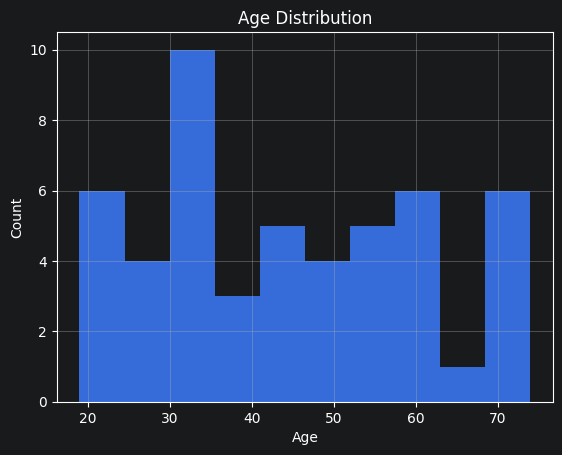

In [34]:
# What kind of patient population does this hospital serve?
patients['age'].hist()
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()


# Does the hospital have balanced specialist coverage?


In [35]:
# Experience distribution
doctors['years_experience'].describe()

count    10.0000
mean     21.5000
std       6.7536
min       5.0000
25%      19.5000
50%      23.5000
75%      26.0000
max      28.0000
Name: years_experience, dtype: float64

In [36]:
# Specializations count
doctors['specialization'].value_counts()

specialization
Pediatrics     5
Dermatology    3
Oncology       2
Name: count, dtype: int64

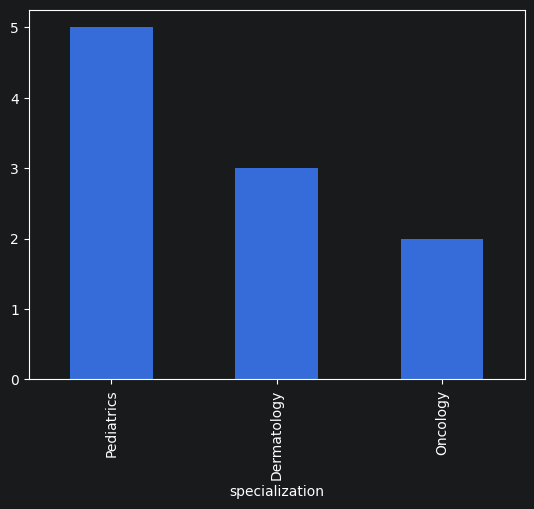

In [37]:
doctors['specialization'].value_counts().plot(kind='bar')
plt.show()

# How much money is actually being collected?

In [38]:
# payment status
billing['payment_status'].value_counts()

payment_status
Pending    69
Failed     67
Paid       64
Name: count, dtype: int64

In [39]:
# Revenue summary
billing['amount'].describe()

count     200.000000
mean     2756.249250
std      1298.125308
min       534.030000
25%      1563.412500
50%      2828.165000
75%      3836.627500
max      4973.630000
Name: amount, dtype: float64

In [40]:
# Total Revenue by payment status
billing.groupby('payment_status')['amount'].sum()


payment_status
Failed     193212.94
Paid       173424.90
Pending    184612.01
Name: amount, dtype: float64

In [41]:
# Merging billing and treatments tables
billing_treatment = billing.merge(treatments, on= 'treatment_id')
billing_treatment

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status,appointment_id,treatment_type,description,cost,treatment_date
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid,A003,MRI,Standard procedure,3731.55,2023-06-28
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed,A004,MRI,Basic screening,4799.86,2023-09-01
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending,A005,ECG,Standard procedure,582.05,2023-07-06
...,...,...,...,...,...,...,...,...,...,...,...,...
195,B196,P045,T196,2023-10-26,2477.80,Cash,Pending,A196,Chemotherapy,Advanced protocol,2477.80,2023-10-26
196,B197,P001,T197,2023-04-01,975.49,Cash,Pending,A197,Physiotherapy,Standard procedure,975.49,2023-04-01
197,B198,P022,T198,2023-05-15,3383.72,Cash,Failed,A198,ECG,Basic screening,3383.72,2023-05-15
198,B199,P017,T199,2023-05-01,1472.17,Credit Card,Paid,A199,Chemotherapy,Basic screening,1472.17,2023-05-01


In [42]:
# Which treatment types generate highest revenue?
billing_treatment.groupby('treatment_type')['cost'].sum().sort_values(ascending=False)

treatment_type
Chemotherapy     128855.68
MRI              116098.16
X-Ray            110653.67
Physiotherapy     99418.10
ECG               96224.24
Name: cost, dtype: float64

# Anomalies investigation, why does patient P012 have huge spending despite cancellations/no-shows?

In [43]:
full_data = billing_treatment.merge(appointments, on= 'appointment_id')

In [44]:
full_data = full_data.rename(columns={'patient_id_x' : 'patient_id'})
full_data = full_data.drop(columns='patient_id_y')

In [45]:
full_data

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status,appointment_id,treatment_type,description,cost,treatment_date,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending,A001,Chemotherapy,Basic screening,3941.97,2023-08-09,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid,A002,MRI,Advanced protocol,4158.44,2023-06-09,D004,2023-06-09,14:30:00,Therapy,No-show
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid,A003,MRI,Standard procedure,3731.55,2023-06-28,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed,A004,MRI,Basic screening,4799.86,2023-09-01,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending,A005,ECG,Standard procedure,582.05,2023-07-06,D003,2023-07-06,12:45:00,Emergency,No-show
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,B196,P045,T196,2023-10-26,2477.80,Cash,Pending,A196,Chemotherapy,Advanced protocol,2477.80,2023-10-26,D006,2023-10-26,9:45:00,Checkup,Cancelled
196,B197,P001,T197,2023-04-01,975.49,Cash,Pending,A197,Physiotherapy,Standard procedure,975.49,2023-04-01,D005,2023-04-01,13:30:00,Emergency,No-show
197,B198,P022,T198,2023-05-15,3383.72,Cash,Failed,A198,ECG,Basic screening,3383.72,2023-05-15,D006,2023-05-15,8:30:00,Therapy,No-show
198,B199,P017,T199,2023-05-01,1472.17,Credit Card,Paid,A199,Chemotherapy,Basic screening,1472.17,2023-05-01,D001,2023-05-01,12:45:00,Follow-up,Completed


In [46]:
# Why does this patient have huge spending despite cancellations/no-shows?
p012 = full_data[full_data['patient_id']== 'P012']
p012

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status,appointment_id,treatment_type,description,cost,treatment_date,doctor_id,appointment_date,appointment_time,reason_for_visit,status
13,B014,P012,T014,2023-05-25,2082.30,Credit Card,Paid,A014,ECG,Basic screening,2082.30,2023-05-25,D010,2023-05-25,10:30:00,Emergency,Cancelled
27,B028,P012,T028,2023-10-29,1315.17,Credit Card,Paid,A028,Chemotherapy,Standard procedure,1315.17,2023-10-29,D006,2023-10-29,15:30:00,Checkup,No-show
61,B062,P012,T062,2023-06-14,3139.74,Cash,Paid,A062,X-Ray,Standard procedure,3139.74,2023-06-14,D009,2023-06-14,15:15:00,Checkup,No-show
68,B069,P012,T069,2023-03-29,3388.87,Credit Card,Paid,A069,MRI,Basic screening,3388.87,2023-03-29,D004,2023-03-29,15:30:00,Therapy,Cancelled
78,B079,P012,T079,2023-12-26,2319.43,Insurance,Paid,A079,X-Ray,Basic screening,2319.43,2023-12-26,D002,2023-12-26,14:00:00,Follow-up,Cancelled
121,B122,P012,T122,2023-07-11,3902.73,Insurance,Failed,A122,X-Ray,Standard procedure,3902.73,2023-07-11,D008,2023-07-11,14:30:00,Therapy,Cancelled
139,B140,P012,T140,2023-02-05,4019.13,Cash,Pending,A140,Physiotherapy,Standard procedure,4019.13,2023-02-05,D005,2023-02-05,15:15:00,Checkup,No-show
142,B143,P012,T143,2023-09-21,1864.08,Insurance,Failed,A143,MRI,Standard procedure,1864.08,2023-09-21,D007,2023-09-21,12:15:00,Checkup,Cancelled
153,B154,P012,T154,2023-03-06,4637.26,Cash,Failed,A154,X-Ray,Basic screening,4637.26,2023-03-06,D006,2023-03-06,17:30:00,Emergency,No-show
173,B174,P012,T174,2023-10-31,3384.37,Cash,Paid,A174,Chemotherapy,Standard procedure,3384.37,2023-10-31,D002,2023-10-31,11:15:00,Follow-up,Cancelled


In [47]:
full_data.groupby('status')['amount'].agg(['count', 'sum', 'mean'])

,count,sum,mean
status,,,
Cancelled,51,152044.88,2981.272157
Completed,46,124100.46,2697.836087
No-show,52,142677.81,2743.804038
Scheduled,51,132426.70,2596.601961


In [48]:
# An unexpected anomaly was discovered during billing analysis.

# Completed appointments generated $124,100 in revenue.

# However, canceled appointments generated $152,044, while no-show appointments generated $142,677.

# This indicates that appointments not resulting in completed medical services are still generating revenue at a level higher than successfully completed appointments.

# Possible explanation:

# The hospital billing system may be generating invoices before service delivery, without reversing charges after cancellations or no-shows.

# Business risk:

# This may lead to inflated revenue reporting, billing disputes, and poor customer experience.

# anomaly visualization

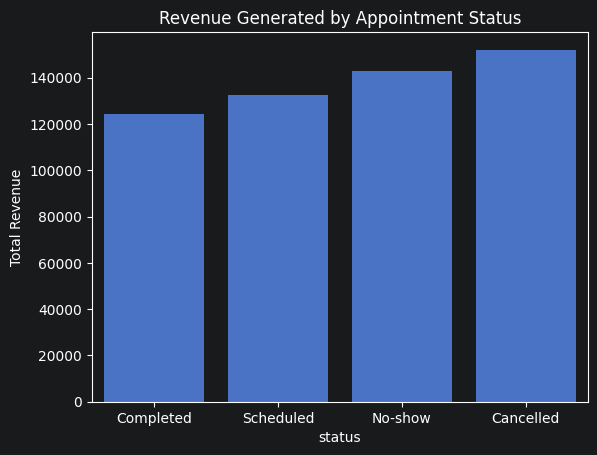

In [79]:
status_revenue = full_data.groupby('status')['amount'].sum().reset_index()
status_revenue = status_revenue.sort_values('amount', ascending=True)

sns.barplot(
    x='status',
    y='amount',
    data=status_revenue
)

plt.title('Revenue Generated by Appointment Status')
plt.ylabel('Total Revenue')
plt.show()

# Payment success rate by payment method comparison

In [80]:
payment_rate = pd.crosstab(
    billing['payment_method'],
    billing['payment_status'],
    normalize='index'
) * 100

payment_rate


payment_status,Failed,Paid,Pending
payment_method,,,
Cash,37.704918,32.786885,29.508197
Credit Card,30.666667,32.000000,37.333333
Insurance,32.812500,31.250000,35.937500


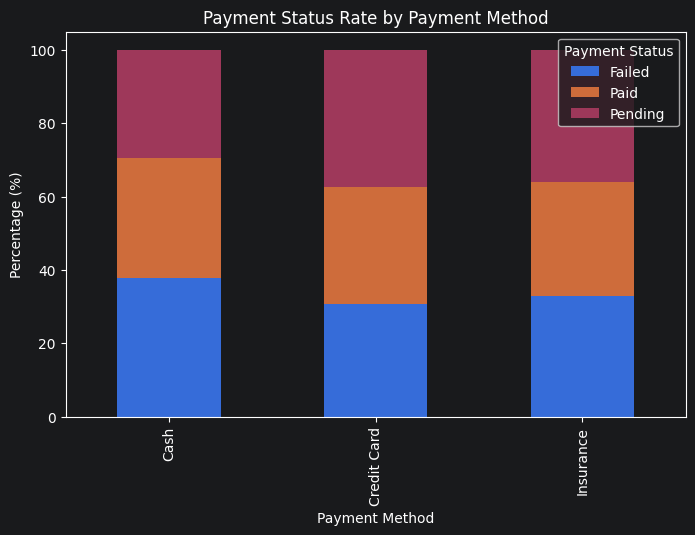

In [88]:
payment_rate.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Payment Status Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.legend(title="Payment Status")
plt.show()

# Which doctors generate highest revenue

In [57]:
doctors_revenue = full_data.groupby('doctor_id')['amount'].sum().sort_values(ascending=False)
doctors_revenue

doctor_id
D005    82696.48
D006    69586.10
D001    66585.39
D002    59803.46
D008    53427.42
D003    52791.41
D010    49436.23
D007    40166.50
D004    39315.95
D009    37440.91
Name: amount, dtype: float64

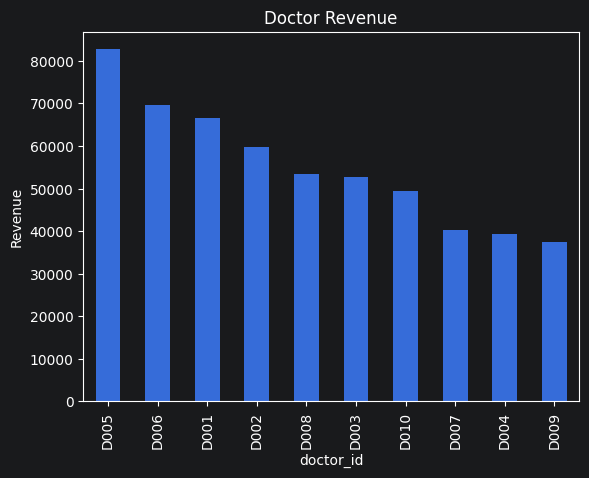

In [58]:
doctors_revenue.plot(kind = 'bar')

plt.title('Doctor Revenue')
plt.ylabel('Revenue')
plt.show()

In [69]:
doctors_appointment = full_data.groupby('doctor_id')['appointment_id'].count().sort_values(ascending=False)
doctors_appointment

doctor_id
D005    29
D001    25
D006    24
D003    22
D002    21
D010    19
D009    17
D008    16
D004    14
D007    13
Name: appointment_id, dtype: int64

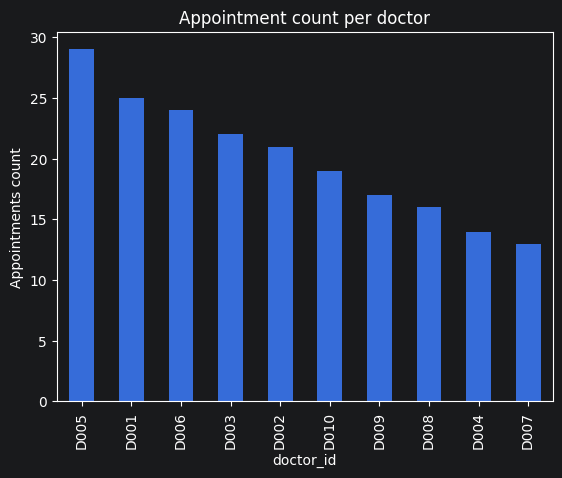

In [77]:
doctors_appointment.plot(kind = 'bar')

plt.title('Appointment count per doctor')
plt.ylabel('Appointments count')
plt.show()

In [93]:
doctor_performance = full_data.groupby('doctor_id').agg({
    'appointment_id':'count',
    'amount':'sum'
})

doctor_performance['revenue_per_appointment'] = (
    doctor_performance['amount'] /
    doctor_performance['appointment_id']
)

doctor_performance.sort_values(
    'revenue_per_appointment',
    ascending=False
)

,appointment_id,amount,revenue_per_appointment
doctor_id,,,
D008,16,53427.42,3339.213750
D007,13,40166.50,3089.730769
D006,24,69586.10,2899.420833
D005,29,82696.48,2851.602759
D002,21,59803.46,2847.783810
D004,14,39315.95,2808.282143
D001,25,66585.39,2663.415600
D010,19,49436.23,2601.906842
D003,22,52791.41,2399.609545


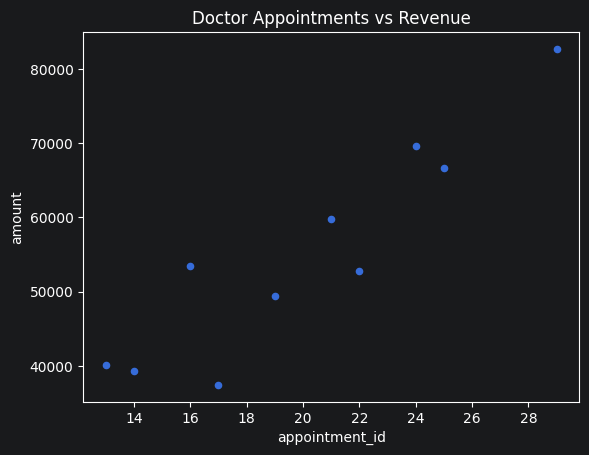

In [94]:
doctor_performance.plot.scatter(
    x='appointment_id',
    y='amount'
)

plt.title("Doctor Appointments vs Revenue")
plt.show()

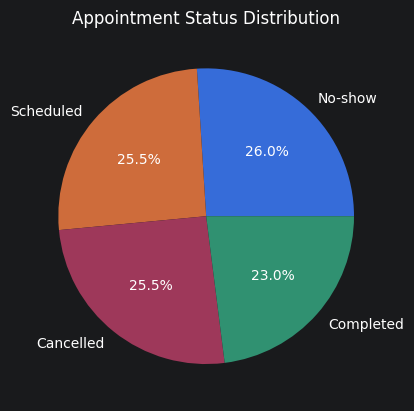

In [72]:
# How much operational waste exists due to cancellations?
appointments['status'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Appointment Status Distribution')
plt.ylabel("")
plt.show()

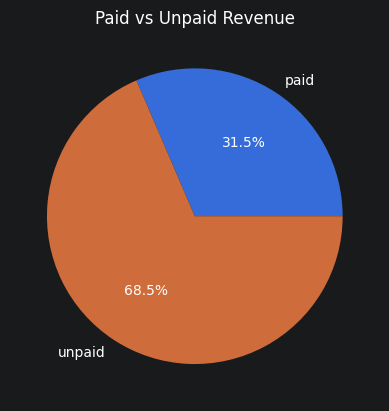

In [76]:
# How much money is stuck in unpaid bills?
unpaid = billing[billing['payment_status'].isin(['Pending','Failed'])]
paid = billing[billing['payment_status'] == 'Paid']

labels = ['paid','unpaid']
values = [paid['amount'].sum(),unpaid['amount'].sum()]

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title('Paid vs Unpaid Revenue')
plt.show()



# Executive Summary

This project analyzes operational and financial performance of a hospital management system using SQL and Python.

By analyzing patient demographics, billing data, appointments, treatments, and doctor activity, several operational inefficiencies and financial anomalies were identified.

The analysis focuses on revenue generation, payment collection, appointment management, and anomaly detection.

# Key Findings
1. Cancelled appointments generated more revenue than completed appointments.

2. 68.5% of total revenue remains unpaid.

3. Only 23% of appointments resulted in completed service delivery.

4. Patient P012 was identified as an anomaly, spending over $30,000 despite having zero completed appointments.

5. High-value treatments such as Chemotherapy and MRI generate most hospital revenue.

6. Doctor D008 handles fewer patients but generates the highest revenue per appointment.

7. Doctors with low appointment volume may still contribute strongly through higher-value treatments like D007.

# Business Recommendations

1. Review billing workflow to prevent invoices being generated before service completion.

2. Improve payment collection processes to reduce unpaid revenue.

3. Investigate causes behind high cancellation and no-show rates.

4. Prioritize high-revenue treatment services such as MRI and Chemotherapy.

5. Implement appointment reminder systems to reduce patient no-shows.

# Doctors Insight
Although doctors with higher appointment volume generally generate more revenue overall, revenue efficiency varies significantly across doctors.

Doctor D008 generated the highest revenue per appointment ($3339) despite handling only 16 appointments, ranking eighth in appointment volume.

Similarly, Doctor D007 ranked second in revenue efficiency despite handling the fewest appointments.

This suggests that treatment specialization may play a larger role in profitability than appointment volume alone.

Recommendation:

Hospital management should investigate high-performing specialists and identify service lines contributing disproportionately high revenue.

# Data Quality / Business Logic Concerns
During exploratory analysis, several anomalies were detected suggesting that the dataset is synthetically generated rather than representing real hospital operations.

Findings:

• Canceled appointments generated more revenue than completed appointments.

• Patients marked as "No-show" were still associated with completed treatments and billing records.

• One patient (P012) had 100% of appointments marked Canceled or No-show, yet was billed for every treatment.

These inconsistencies indicate that billing records may have been generated independently of appointment outcomes.

In [95]:
doctors[['doctor_id', 'specialization']]

,doctor_id,specialization
0,D001,Dermatology
1,D002,Pediatrics
2,D003,Pediatrics
3,D004,Pediatrics
4,D005,Dermatology
5,D006,Pediatrics
6,D007,Oncology
7,D008,Dermatology
8,D009,Pediatrics
9,D010,Oncology


In [98]:
full_data.to_csv(
    r"C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Hospital_Data_Analytics_Project\Python\hospital_full_data.csv",
    index=False
)